## **GRU Model**

The presented dataset contains longitudinal data which may hide temporal relations with injury incidence. For this reason, we present in this notebook a sequential gated recurrent unit (GRU) model able to capture these temporal dependencies and provide more accurate predictions of injury risk than state-of-the-art models. 

In [451]:
# Dependencies
import copy
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Torch
import torch
import torch.nn as nn
import pandas as pd
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler

# Sklearn metrics
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [452]:
print(device) # Check device (we recommend to use cuda for faster training)

cuda


In [453]:
# Data loading
day_path = 'Dataset/day_approach_maskedID_timeseries.csv'

# Day and week dataframes
day_df = pd.read_csv(day_path)

Our model will be trained under specific hyper-parameter combinations:

We performed a hyper-parameter tuning using grid search:
- **sequence_length**: Length of time points included in a sequence window
- **hidden_size**: Number of features contained at the hidden state
- **num_layer**: Number of stacked GRU layers
- **dropout**: Rate of random deactivation of neurons
- **injury_threshold**: Minimum number of injury events required to include an athlete in the training dataset
- **weight_factor**: Factor for scaling the weight of minority class in the weighted BCE loss function

These other hyper-parameters were fixed during benchmark
- **epochs**: Number of epochs (Model iterating the whole dataset).
- **lr**: Learning rate (How fast the model optimizes its parameters).
- **batch_size**: Number of samples per iteration
- **patience**: Number of steps to trigger early-stopping during training under a specific condition (in our case that validation loss increses)




In [454]:
# Model hyper-parameter selection
sequence_length = 30
hidden_size = 60
num_layers = 4
dropout = 0.2
injury_threshold = 10
weight_factor = 5

# Fixed hyper-parameter
epochs = 500
lr = 8e-5
batch_size = 512
patience = 15

In [455]:
# Finally, set random seeds for reproducibility
SEED = 1
torch.manual_seed(SEED)
np.random.seed(SEED)

# If using cuda or gpu:
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

### **Exploratory Data Analysis**

In this section, we are going to inspect the structure and quality of the dataset to determine which strategy could be optimal to predict injury incidence. 

In [456]:
df = day_df.copy()

# Split of datasets
injury_df = df[df['injury']==1]
healthy_df = df[df['injury']==0]

# Injury data points are clearly unbalanced
print(f'Injury data points: {injury_df.shape[0]}')
print(f'Healthy data points: {healthy_df.shape[0]}')
print(f'Proportion of injury data points among the data set: {injury_df.shape[0] / (injury_df.shape[0] + healthy_df.shape[0])}')

Injury data points: 583
Healthy data points: 42183
Proportion of injury data points among the data set: 0.013632324743955478


Very few injury data points in comparison to healthy ones (~1%), the model would need to handle this minority class issue

In [457]:
# Count of data points, injury points and injury proportion per athlete 
athlete_analysis = (
    df.groupby("Athlete ID", as_index=False)
      .agg(
          data_points=("injury", "size"),      # rows per athlete
          injury_events=("injury", "sum")      # number of injury=1 rows
      )
)

athlete_analysis["injury_proportion"] = (
    athlete_analysis["injury_events"] / athlete_analysis["data_points"]
)

athlete_analysis 

,Athlete ID,data_points,injury_events,injury_proportion
0,0,310,7,0.022581
1,1,461,2,0.004338
2,2,1291,4,0.003098
3,3,344,3,0.008721
4,4,681,7,0.010279
...,...,...,...,...
69,69,314,5,0.015924
70,70,327,5,0.015291
71,71,392,5,0.012755
72,72,216,0,0.000000


At the individual athlete level, clear differences can be observed between athletes. To ensure homogeneity in the data and reduce athlete-specific bias, a preprocessing pipeline is required so that the model learns general underlying patterns associated with injury risk instead of patterns driven by individual athletes.

In [458]:
# Summary stats for data point counts
count_stats = athlete_analysis["data_points"].agg(["max", "min", "mean", "std"])

# Summary stats for injury event counts
injury_event_stats = athlete_analysis["injury_events"].agg(["max", "min", "mean", "std"])

# Summary stats for injury proportion
injury_prop_stats = athlete_analysis["injury_proportion"].agg(["max", "min", "mean", "std"])

print("Data points per athlete stats:")
print(count_stats)

print("\nInjury events per athlete stats:")
print(injury_event_stats)

print("\nInjury proportion per athlete stats:")
print(injury_prop_stats)

# We can say that each athlete has around 600 recorded training whereby 7 lead to injury 

Data points per athlete stats:
max     1791.000000
min       43.000000
mean     577.918919
std      425.929274
Name: data_points, dtype: float64

Injury events per athlete stats:
max     35.000000
min      0.000000
mean     7.878378
std      8.261070
Name: injury_events, dtype: float64

Injury proportion per athlete stats:
max     0.045205
min     0.000000
mean    0.012959
std     0.011092
Name: injury_proportion, dtype: float64


Here we observe that the per-athlete data is highly unbalanced with respect to injury events and the number of recorded sessions. Some athletes do not experience any injuries throughout the entire training period, while others are injured more than 30 times. A similar imbalance is present in the number of recorded sessions: some athletes exceed 1,000 sessions, whereas others barely reach 100. On average, each athlete has approximately 600 recorded training sessions, of which around 7 are associated with injury, corresponding to an injury proportion of 1.30%.

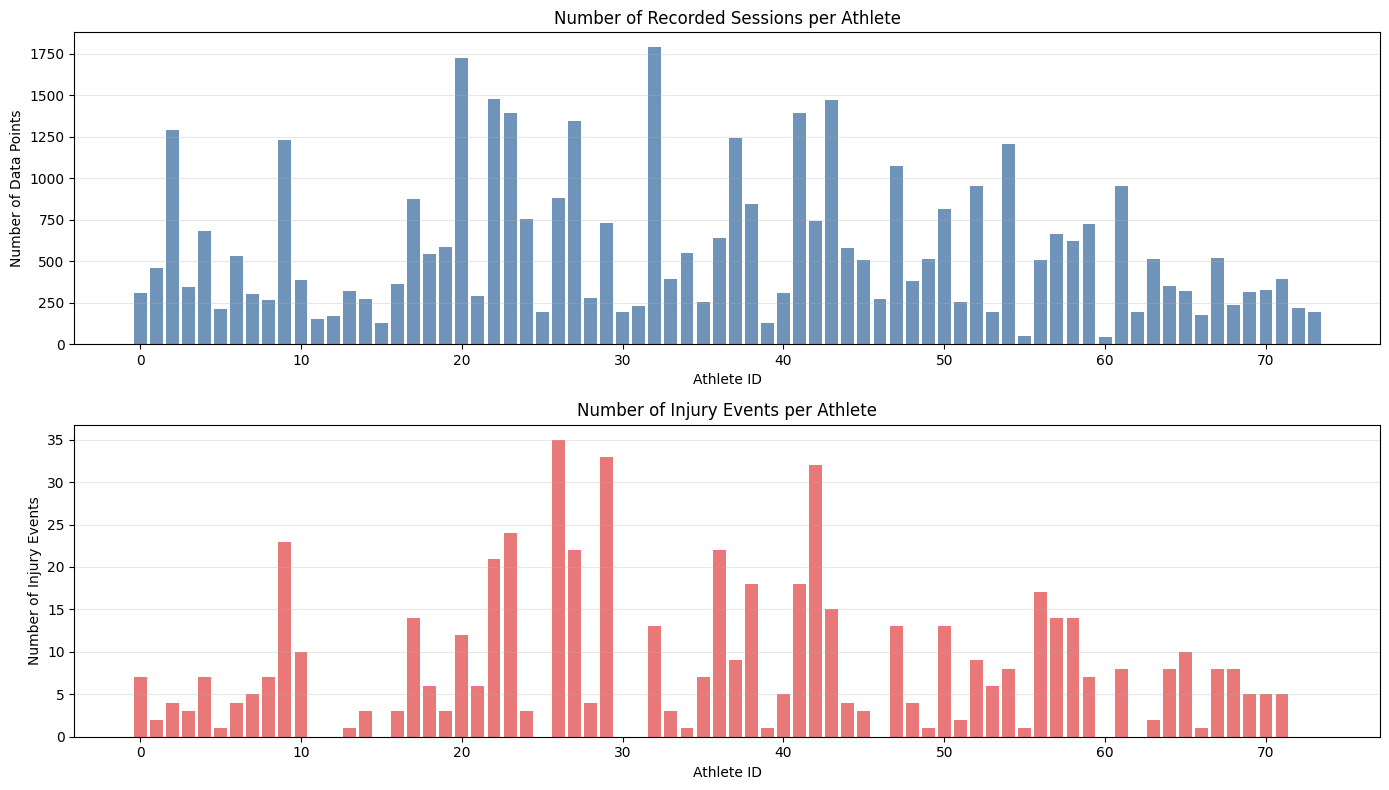

In [459]:
# Create histogram plots of data points and injuries per athlete (ordered by athlete ID)
athlete_data_sorted = athlete_analysis.sort_values("Athlete ID").reset_index(drop=True)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Plot 1: Number of data points per athlete
axes[0].bar(range(len(athlete_data_sorted)), athlete_data_sorted["data_points"], color="#4C78A8", alpha=0.8)
axes[0].set_xlabel("Athlete ID")
axes[0].set_ylabel("Number of Data Points")
axes[0].set_title("Number of Recorded Sessions per Athlete")
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: Number of injuries per athlete
axes[1].bar(range(len(athlete_data_sorted)), athlete_data_sorted["injury_events"], color="#E45756", alpha=0.8)
axes[1].set_xlabel("Athlete ID")
axes[1].set_ylabel("Number of Injury Events")
axes[1].set_title("Number of Injury Events per Athlete")
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


Let’s analyze in more detail how injuries evolve across the dataset by defining transitions in the binary injury label. This approach allows us to quantify the process of becoming injured, remaining injured and returning to training after an injury. 

In [460]:
# Create analysis dataframe
analysis_df = day_df.copy()

# Sort chronologically inside each athlete
analysis_df = (
    analysis_df
    .sort_values(["Athlete ID", "Date"])
    .reset_index(drop=True)
)

# Time gap feature days between consecutive records of same athlete
analysis_df["transition_period_days"] = (
    analysis_df
    .groupby("Athlete ID")["Date"]
    .diff()
    .fillna(0)
    .astype(int)
)

# Transition feature from previous injury state to current injury state
prev_injury = (
    analysis_df
    .groupby("Athlete ID")["injury"]
    .shift(1)
    .fillna(0)
    .astype(int)
)
curr_injury = analysis_df["injury"].astype(int)

analysis_df["transition"] = prev_injury.astype(str) + "->" + curr_injury.astype(str)

# Numeric encoding for model use
transition_map = {"0->0": 0, "0->1": 1, "1->0": 2, "1->1": 3}
analysis_df["transition_code"] = analysis_df["transition"].map(transition_map).astype("Int64")


# Counts and proportion of transitions
transition_counts = analysis_df["transition"].value_counts().sort_index()
transition_props = analysis_df["transition"].value_counts(normalize=True).sort_index()

# Statistical summary (0->0 dominates heavily)
transition_stats = pd.DataFrame({
    "count": transition_counts,
    "proportion": transition_props
})

print("Transition type stats:")
print(transition_stats)

Transition type stats:
            count  proportion
transition                   
0->0        41818    0.977833
0->1          393    0.009190
1->0          365    0.008535
1->1          190    0.004443


These transition statistics highlight the very limited representation of injured states in the dataset. In addition, we observe periods where athletes remain in the injured state, which may suggest either recurrent injuries or the possibility that athletes continue to tolerate training load while already injured. To distinguish between these scenarios, additional information on the injury status is required. 

Another aspect to explore is the presence of gaps and their associated transitions. This dataset contains discontinuities between recording sessions, reflected in multi-day jumps in the `Date` variable.

In [461]:
# Statistical summary of discontinuity transition period days per transition types
tp_by_transition = (
    analysis_df
    .groupby("transition")["transition_period_days"]
    .agg(["count", "mean", "std", "min", "median", "max"])
    .sort_index()
)

print("\nTransition period by transition type:")
print(tp_by_transition)


Transition period by transition type:
            count       mean        std  min  median  max
transition                                               
0->0        41818   1.093787   4.901191    0     1.0  649
0->1          393  26.076336  22.393610    0    22.0  259
1->0          365  34.767123  25.139020   22    25.0  236
1->1          190  50.647368  38.226378   22    40.0  278


We observe that periods in which the athlete remains uninjured tend to include the longest gaps in recorded sessions, suggesting temporary interruptions that may be due to factors other than injury. It is important to note that this dataset spans multiple years, so such gaps may reflect a variety of causes.

However, the key information emerges around injury events. After an injury occurs, athletes appear to stop training for a period of at least 22 days. If we assume that transitions from injury to injury represent relapses, and that an injury event renders the athlete unable to perform any training aside from rehabilitation, this pattern suggests the existence of a structured protocol in which athletes remain without recorded training sessions for a defined recovery period following injury.

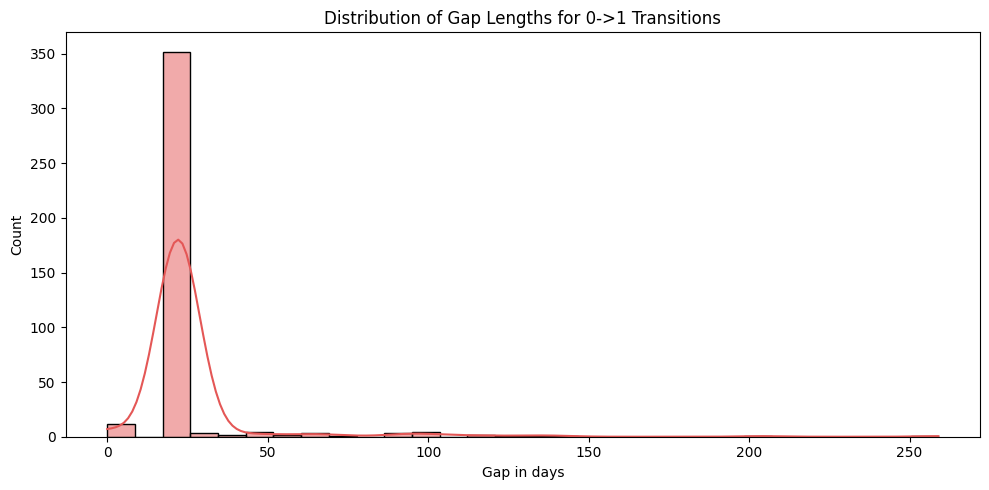

In [462]:
# Gaps for 0->1 transitions only
gaps_01 = analysis_df.loc[analysis_df["transition"] == "0->1", "transition_period_days"]

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(gaps_01, bins=30, kde=True, color="#E45756", ax=ax)

ax.set_title("Distribution of Gap Lengths for 0->1 Transitions")
ax.set_xlabel("Gap in days")
ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

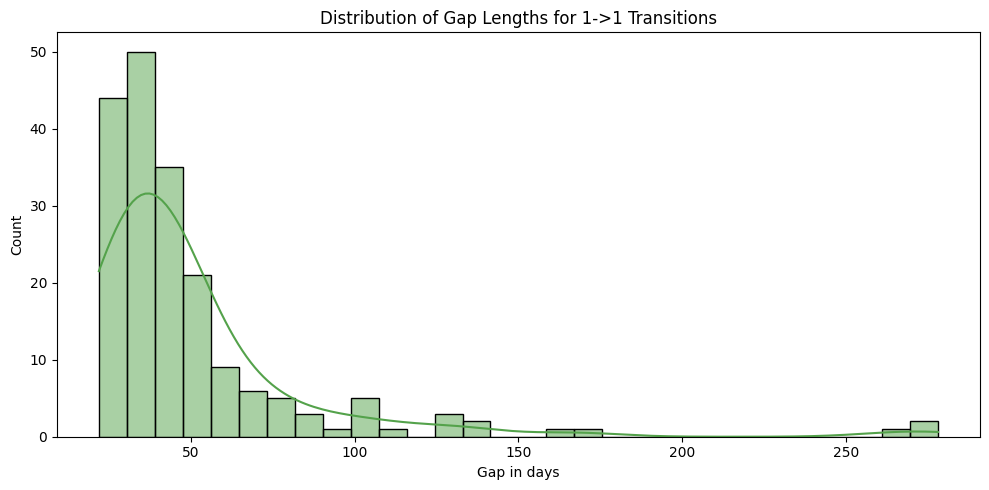

In [463]:
# Gaps for 1->1 transitions
gaps_11 = analysis_df.loc[analysis_df["transition"] == "1->1", "transition_period_days"]

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(gaps_11, bins=30, kde=True, color="#54A24B", ax=ax)

ax.set_title("Distribution of Gap Lengths for 1->1 Transitions")
ax.set_xlabel("Gap in days")
ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

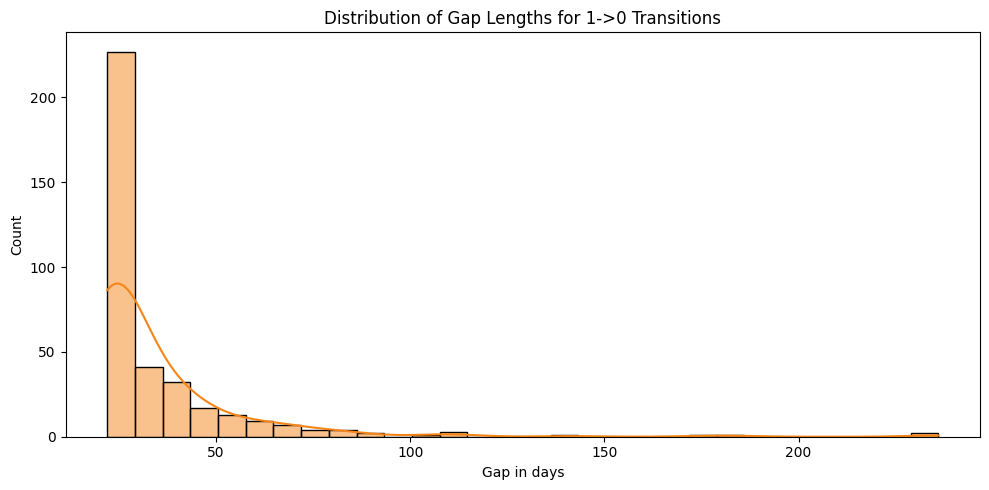

In [464]:
# Gaps for 1->0 transitions
gaps_10 = analysis_df.loc[analysis_df["transition"] == "1->0", "transition_period_days"]

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(gaps_10, bins=30, kde=True, color="#F58518", ax=ax)

ax.set_title("Distribution of Gap Lengths for 1->0 Transitions")
ax.set_xlabel("Gap in days")
ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

These graphs suggest that when an injury event occurs, there is typically a subsequent period of no training lasting around 20–30 days, during which the athlete is not recorded. However, for transitions from healthy to injured state, we also observe a gap of approximately 22 days, suggesting that the last recorded session may have been misclassified as non-injured or that the injury was diagnosed after the training session had already taken place. Therefore, we need more information and without external medical or coaching confirmation, changing the injury label is speculative.

In conclusion, we are dealing with a highly imbalanced dataset, with substantial variation across athletes. Therefore, it is essential to adopt a strategy that is sensitive to the minority class, capable of capturing this rare injury events effectively. Additionally, several data quality issues (temporal gaps, athlete variability) may further complicate the modeling process.

Our objective is to develop a predictive model for injury occurrence that leverages the temporal relationships between recording sessions, since injury incidence is strongly influenced by cumulated training load over time. This project aims to provide a valuable decision-support tool for coaches and other sports staff involved in designing periodized training plans that enable athletes to train consistently while minimizing injury risk.

Beyond professional sports, we believe this framework could also be extended to broader health-oriented contexts. By incorporating additional longitudinal features, such as biomarkers, recovery indicators, and lifestyle-related variables, the system could support the monitoring of general well-being and help evaluate and predict health-related outcomes beyond injury prevention alone.

### **Baseline Logistic Regression Model**

In this section, we train and evaluate a simple logistic regression model, which serves as a baseline for comparing the performance of our GRU model. The data preprocessing and model evaluation pipelines were performed to match the GRU preprocessing procedure as closely as possible.

Remaining athletes: 19
Remaining rows: 20223
Best threshold (validated on validation set): 0.49
Validation balanced accuracy at best threshold: 0.6302
Validation ROC AUC: 0.6553
Test Accuracy: 0.6342
Test Specificity (TNR): 0.6388
Test Sensitivity (TPR): 0.3947
Test Balanced Accuracy: 0.5168
Test ROC AUC: 0.5706


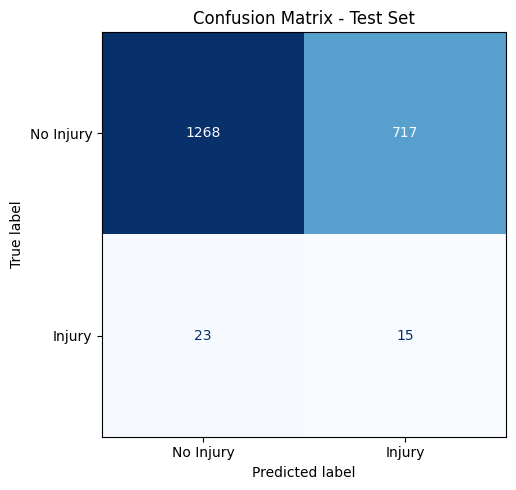

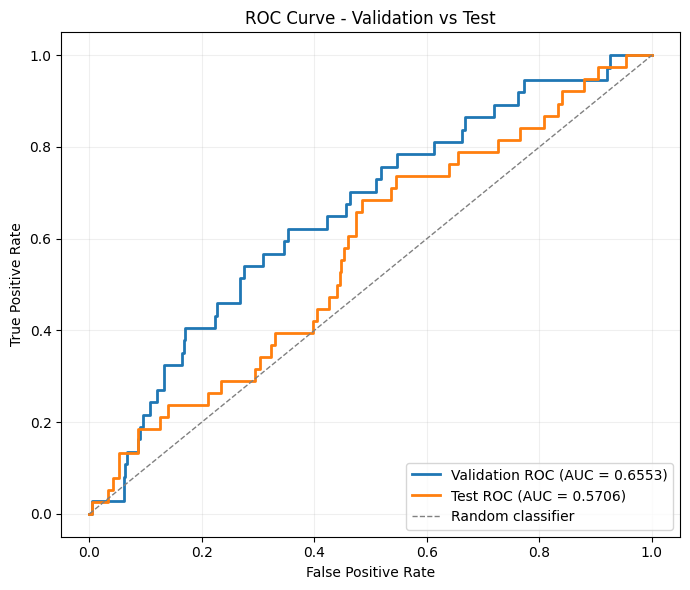

In [478]:
# Keep only athletes above injury threshold (we will do the same procedure for GRU)
athlete_injuries = day_df.groupby("Athlete ID")["injury"].sum()
eligible_athletes = athlete_injuries[athlete_injuries > injury_threshold].index
df = day_df[day_df["Athlete ID"].isin(eligible_athletes)].copy()

print(f"Remaining athletes: {df['Athlete ID'].nunique()}")
print(f"Remaining rows: {len(df)}")

# Tabular baseline features,
feature_cols = [c for c in df.columns if c not in ["injury", "Date"]]
X = df[feature_cols].copy()
y = df["injury"].astype(int).copy()

# Fill missing values if needed
X = X.fillna(X.median(numeric_only=True))

# Split by rows, stratified by label
X_train, X_valtest, y_train, y_valtest = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=SEED,
    stratify=y,
)

X_val, X_test, y_val, y_test = train_test_split(
    X_valtest,
    y_valtest,
    test_size=0.5,
    random_state=SEED,
    stratify=y_valtest,
)

# Standardize features
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

# Logistic regression baseline
clf = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=SEED,
)
clf.fit(X_train_s, y_train)

# Probabilities
y_val_probs = clf.predict_proba(X_val_s)[:, 1]
y_test_probs = clf.predict_proba(X_test_s)[:, 1]

# Validation ROC
val_fpr, val_tpr, _ = roc_curve(y_val, y_val_probs)
val_roc_auc = auc(val_fpr, val_tpr)

# Tune threshold on validation set using balanced accuracy
threshold_grid = np.linspace(0.01, 0.99, 99)
val_scores = []

for threshold in threshold_grid:
    val_preds = (y_val_probs >= threshold).astype(int)
    val_scores.append(balanced_accuracy_score(y_val, val_preds))

best_threshold = threshold_grid[int(np.argmax(val_scores))]
best_val_balanced_accuracy = float(np.max(val_scores))

# Test predictions
y_test_pred = (y_test_probs >= best_threshold).astype(int)

# Metrics
test_accuracy = accuracy_score(y_test, y_test_pred)
test_balanced_accuracy = balanced_accuracy_score(y_test, y_test_pred)
test_roc_auc = roc_auc_score(y_test, y_test_probs)

cm = confusion_matrix(y_test, y_test_pred)
fpr, tpr, _ = roc_curve(y_test, y_test_probs)
roc_auc = auc(fpr, tpr)

# Compute sensitivity and specificity from confusion matrix
tn, fp, fn, tp = cm.ravel()

test_sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
test_specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

print(f"Best threshold (validated on validation set): {best_threshold:.2f}")
print(f"Validation balanced accuracy at best threshold: {best_val_balanced_accuracy:.4f}")
print(f"Validation ROC AUC: {val_roc_auc:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Specificity (TNR): {test_specificity:.4f}")
print(f"Test Sensitivity (TPR): {test_sensitivity:.4f}")
print(f"Test Balanced Accuracy: {test_balanced_accuracy:.4f}")
print(f"Test ROC AUC: {test_roc_auc:.4f}")
# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Injury", "Injury"])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
ax.set_title("Confusion Matrix - Test Set")
plt.tight_layout()
plt.show()

# ROC curves
plt.figure(figsize=(7, 6))
plt.plot(val_fpr, val_tpr, label=f"Validation ROC (AUC = {val_roc_auc:.4f})", linewidth=2, color="#1f77b4")
plt.plot(fpr, tpr, label=f"Test ROC (AUC = {roc_auc:.4f})", linewidth=2, color="#ff7f0e")
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1, color="grey", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Validation vs Test")
plt.legend(loc="lower right")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

From the ROC curves and the confusion matrix, we observe that this baseline approach struggles to predict injury risk accurately (which in this case is for the next day session). 

### **Data Preprocessing**

The model inputs are split into features and labels. The features contain the columns that the model uses to predict the injury risk (matrix of numerical column vectors), while the label tells the actual injury status (binary vector). For the features that we are using to train the model, we exclude the ID of the athlete to avoid bias and the date because of temporal gaps. Our model aims to provide general predictions within window's temporal range regardless of the athlete. 

In [466]:
# Create a dataframe excluding athletes who never had an injury
day_df = pd.read_csv(day_path, parse_dates=['Date'])
athletes_with_injury = day_df.groupby('Athlete ID')['injury'].sum() > injury_threshold
athletes_with_injury = athletes_with_injury[athletes_with_injury].index

# Filter original dataframe to keep only those athletes
day_df_injured = day_df[day_df['Athlete ID'].isin(athletes_with_injury)].copy()

print(day_df_injured['Athlete ID'].nunique())

19


/tmp/ipykernel_2528789/637679367.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  day_df = pd.read_csv(day_path, parse_dates=['Date'])


For data preprocessing, we remove redundant variables. Among the features used to predict the label, we exclude `Date`, since the data points are already chronologically ordered. Including this variable could lead the model to learn temporal gaps directly, which we believe may hinder its ability to capture the underlying patterns associated with injury development. Similarly, we exclude `Athlete_ID`, as it could introduce athlete-specific biases into the model rather than learning generalized injury-related patterns.

In [ ]:
# Remove redudant variables
base_features = [
"Athlete ID",
"Date",
"injury",
"nr. sessions",
"total km",
"km Z3-4",
"km Z5-T1-T2",
"km sprinting",
"strength training",
"hours alternative",
"perceived exertion",
"perceived trainingSuccess",
"perceived recovery",
]

# Build our dataset and our feature cols for the inputs, removing unwanted variables
df = day_df_injured[base_features].sort_values(by=['Athlete ID', 'Date'])
df = df.sort_values(["Athlete ID", "Date"]).copy()
feature_cols = [c for c in df.columns if c not in ["injury", "Date", "Athlete_ID"]] 


# Generate inputs containing the sequences of features and labels
sequence_frames = [] # Feature sequences
sequence_labels = [] # Label sequences

# We generate the sequences by each athlete individually to avoid temporal windows containing data from different athletes
for _, athlete_df in df.groupby("Athlete ID", sort=False):
    athlete_df = athlete_df.sort_values("Date")
    athlete_features = athlete_df[feature_cols].values.astype(np.float32)  
    athlete_labels = athlete_df["injury"].values.astype(np.float32)



# Split: 80% train, 10% val, 10% test
X_train_raw, X_valtest_raw, y_train, y_valtest = train_test_split(
    X_all,
    y_all,
    test_size=0.2, 
    random_state=SEED,
    stratify=y_all if len(np.unique(y_all)) > 1 else None,
)

X_val_raw, X_test_raw, y_val, y_test = train_test_split(
    X_valtest_raw,
    y_valtest,
    test_size=0.5,
    random_state=SEED,
    stratify=y_valtest if len(np.unique(y_valtest)) > 1 else None,
)

# Normalize with train-only statistics
mu = X_train_raw.mean(axis=(0, 1), keepdims=True)
sigma = X_train_raw.std(axis=(0, 1), keepdims=True)
sigma[sigma == 0] = 1.0

X_train = (X_train_raw - mu) / sigma
X_val = (X_val_raw - mu) / sigma
X_test = (X_test_raw - mu) / sigma

# Turn into tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

In [ ]:
# Remove redudant variables
base_features = [
"Athlete ID",
"Date",
"injury",
"nr. sessions",
"total km",
"km Z3-4",
"km Z5-T1-T2",
"km sprinting",
"strength training",
"hours alternative",
"perceived exertion",
"perceived trainingSuccess",
"perceived recovery",
]

# Build our dataset and our feature cols for the inputs, removing unwanted variables
df = day_df_injured[base_features].sort_values(by=['Athlete ID', 'Date'])
df = df.sort_values(["Athlete ID", "Date"]).copy()
feature_cols = [c for c in df.columns if c not in ["injury", "Date", "Athlete_ID"]] 


# Generate inputs containing the sequences of features and labels
sequence_frames = [] # Feature sequences
sequence_labels = [] # Label sequences

# We generate the sequences by each athlete individually to avoid temporal windows containing data from different athletes
for _, athlete_df in df.groupby("Athlete ID", sort=False):
    athlete_df = athlete_df.sort_values("Date")
    athlete_features = athlete_df[feature_cols].values.astype(np.float32)  
    athlete_labels = athlete_df["injury"].values.astype(np.float32)
    
# Temporal points to build the sequences
for start_idx in range(0, len(athlete_df) - sequence_length + 1, 1): 
    end_idx = start_idx + sequence_length
    sequence_frames.append(athlete_features[start_idx:end_idx]) 
    sequence_labels.append(athlete_labels[end_idx - 1]) # predict the sequence_length day of injury

X_all = np.asarray(sequence_frames, dtype=np.float32)
y_all = np.asarray(sequence_labels, dtype=np.float32)
    
    
# Create mapping of sequence index to athlete ID before splitting
sequence_to_athlete = []
for athlete_id, athlete_df in df.groupby("Athlete ID", sort=False):
    athlete_df = athlete_df.sort_values("Date")
    n_sequences = len(athlete_df) - sequence_length + 1
    sequence_to_athlete.extend([athlete_id] * n_sequences)

sequence_to_athlete = np.array(sequence_to_athlete)

# Split of data: 80% train, 10% val, 10% test
X_train_raw, X_valtest_raw, y_train, y_valtest, seq_train, seq_valtest = train_test_split(
    X_all, y_all, sequence_to_athlete,
    test_size=0.2, random_state=SEED,
    stratify=y_all if len(np.unique(y_all)) > 1 else None,
)

X_val_raw, X_test_raw, y_val, y_test, seq_val, seq_test = train_test_split(
    X_valtest_raw, y_valtest, seq_valtest,
    test_size=0.5, random_state=SEED,
    stratify=y_valtest if len(np.unique(y_valtest)) > 1 else None,
)

# Normalize with train-only statistics
mu = X_train_raw.mean(axis=(0, 1), keepdims=True)
sigma = X_train_raw.std(axis=(0, 1), keepdims=True)
sigma[sigma == 0] = 1.0

X_train = (X_train_raw - mu) / sigma
X_val = (X_val_raw - mu) / sigma
X_test = (X_test_raw - mu) / sigma

# Turn into tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

In [469]:
X_train_t.shape # (num samples, sequence length, num features)

torch.Size([15737, 30, 11])

In [470]:
y_train_t.shape # (num samples, injury label)

torch.Size([15737, 1])

In [471]:
# Class imbalance handling and positive class proportions
num_pos = float((y_train == 1).sum())
num_neg = float((y_train == 0).sum())
pos_weight_value = num_neg / (weight_factor*max(num_pos, 1.0)) # Regularized by a scaling weight factor
print(f"Simple workflow - Positive class weight: {pos_weight_value:.4f}")

label_sets = {
    "Train": y_train,
    "Validation": y_val,
    "Test": y_test,
}

for split_name, labels in label_sets.items():
    positive_ratio = (labels == 1).mean()
    print(f"{split_name}: {positive_ratio:.4%} positives ({int((labels == 1).sum())}/{len(labels)})")

Simple workflow - Positive class weight: 10.9610
Train: 1.7920% positives (282/15737)
Validation: 1.7794% positives (35/1967)
Test: 1.8293% positives (36/1968)


In [472]:
# Ensure that the proportions between the splits are reliable for training and evaluation

# Counts per athlete in each split
train_counts = pd.Series(seq_train).value_counts().sort_index()
val_counts   = pd.Series(seq_val).value_counts().sort_index()
test_counts  = pd.Series(seq_test).value_counts().sort_index()

# Union of athlete IDs
athletes = sorted(set(train_counts.index).union(val_counts.index).union(test_counts.index))

# Build table
df = pd.DataFrame(index=athletes)
df['train_sequences'] = train_counts.reindex(athletes).fillna(0).astype(int)
df['val_sequences']   = val_counts.reindex(athletes).fillna(0).astype(int)
df['test_sequences']  = test_counts.reindex(athletes).fillna(0).astype(int)

# Proportions (relative to each split's total)
df['train_prop'] = df['train_sequences'] / df['train_sequences'].sum()
df['val_prop']   = df['val_sequences']   / df['val_sequences'].sum()
df['test_prop']  = df['test_sequences']  / df['test_sequences'].sum()

# optional: round proportions for readability
df[['train_prop','val_prop','test_prop']] = df[['train_prop','val_prop','test_prop']].round(4)
df = df[['train_prop','val_prop','test_prop']]

print(df)

    train_prop  val_prop  test_prop
9       0.0615    0.0600     0.0600
17      0.0422    0.0376     0.0539
20      0.0850    0.0996     0.0813
22      0.0747    0.0752     0.0635
23      0.0683    0.0747     0.0722
26      0.0416    0.0452     0.0564
27      0.0658    0.0676     0.0747
29      0.0364    0.0280     0.0371
32      0.0896    0.0915     0.0874
36      0.0307    0.0320     0.0320
38      0.0424    0.0427     0.0320
41      0.0696    0.0620     0.0742
42      0.0374    0.0320     0.0320
43      0.0728    0.0742     0.0767
47      0.0533    0.0539     0.0503
50      0.0409    0.0407     0.0315
56      0.0252    0.0208     0.0224
57      0.0332    0.0295     0.0285
58      0.0294    0.0325     0.0340


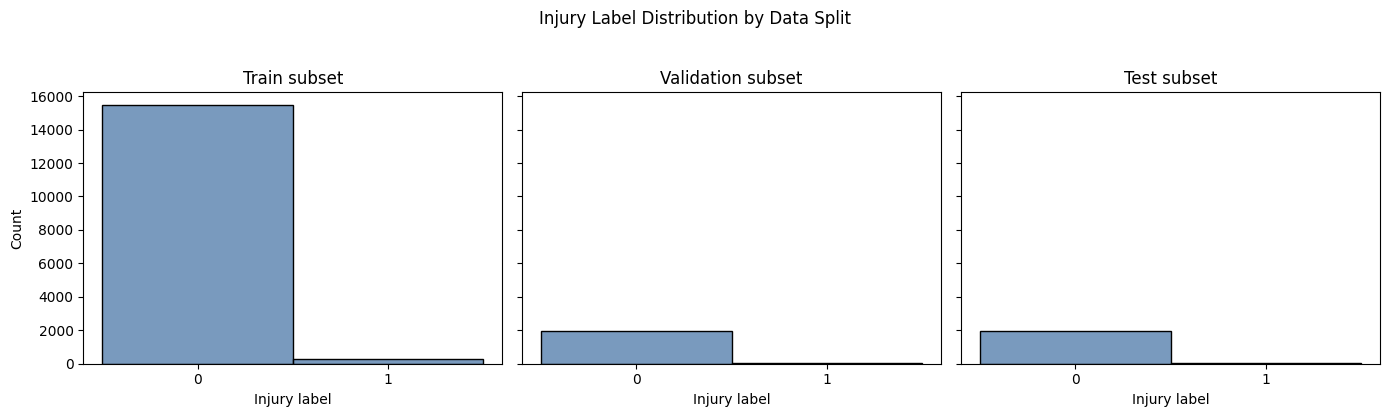

In [473]:
# Injury-label histograms for each split
label_sets = {
    "Train": y_train,
    "Validation": y_val,
    "Test": y_test,
}

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

for ax, (split_name, labels) in zip(axes, label_sets.items()):
    sns.histplot(labels, bins=[-0.5, 0.5, 1.5], discrete=True, ax=ax, color="#4C78A8")
    ax.set_title(f"{split_name} subset")
    ax.set_xlabel("Injury label")
    ax.set_ylabel("Count")
    ax.set_xticks([0, 1])

plt.suptitle("Injury Label Distribution by Data Split", y=1.03)
plt.tight_layout()
plt.show()

We observed that the proportions of positive samples remains the same in all three subsets, as well as the proportion of specific-athlete sequences

### **Model Building and Training**

In this section we will build and train our GRU model. The training includes a validation subset to regularize the generalization capacity of the model with a early-stopping mechanism to avoid overfitting. 

In [474]:
# DataLoaders (we shuffle to avoid biases)
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=batch_size, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=batch_size, shuffle=True)

# Build our GRU model (single GRU layer + linear layer): sequence -> binary output
class GRU(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers=num_layers, batch_first=True, bidirectional=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size * 2, 1)

    def forward(self, x):
        _, h_n = self.gru(x)  # h_n shape: (num_layers*num_directions, batch, hidden_size)
        h_last = torch.cat([h_n[-2], h_n[-1]], dim=1)  # concat forward and backward
        logits = self.fc(h_last)
        return logits
    
# GRU model
input_size = X_train.shape[2]
model = GRU(input_size=input_size, hidden_size=hidden_size).to(device)

# Loss function: Weighted Binary Cross Entropy (BCE) with the proportion of positives as weight
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight_value], dtype=torch.float32, device=device))

# ADAM optimized
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

# Function to evaluate our model (in case of validation subset)
def evaluate(loader, model, criterion, threshold=0.5):
    model.eval() # stop updating parameters, evaluation mode
    total_loss = 0.0
    total_count = 0
    all_probs = []
    all_true = []

    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            probs = torch.sigmoid(logits)

            total_loss += loss.item() * xb.size(0)
            total_count += yb.size(0)
            all_probs.extend(probs.cpu().numpy().flatten().tolist())
            all_true.extend(yb.cpu().numpy().astype(int).flatten().tolist())

    avg_loss = total_loss / max(total_count, 1)
    preds = (np.array(all_probs) >= threshold).astype(int) # positives will be considered those ones above the threshold
    true = np.array(all_true).astype(int)
    return avg_loss, true, np.array(all_probs), preds    

The GRU architecture outputs a raw score (logit) through a linear layer. This logit is transoformed into a probability using a sigmoid activation function.

To deal with the minority class, we selected Weighted BCE as our loss function. It operates the same way that conventional BCE but adds a weight factor $ w_{p} $ that scales the minority positive class (in our case injury) to contribute more in the loss value and therfore in the adjustment of the model's parameters during training.

$$ 
L = -\frac{1}{N} · \Sigma_{i=1}^{N} [w_{p} · y_{i} · log(p_{i}) + (1 - y_{i})log(1 - p_{i})]
$$

- $ N $ is the batch size
- $ p_{i} $ is the predicted probability of the positive class (value between 0 (non-injury) or 1 (injury))
- $ y_{i} $ is the ground truth [0 or 1]

Training loops stores the update in both training and validation losses to plot their evolution over epochs. In a suitable case, both loss curves should have the same decreasing shape. However, in many cases the validation loss curve achieves a plateau while training loss curve continues to diminish. If the validation loss curve start increases, the model is overfitting and we have to trigger an early-stopping mechanism.


========== Training Simple Workflow ==========
Epoch [1/500]  Train Loss: 0.7360 | Val Loss: 0.6542 | Patience: 0/15
Epoch [2/500]  Train Loss: 0.5941 | Val Loss: 0.5402 | Patience: 0/15
Epoch [3/500]  Train Loss: 0.5321 | Val Loss: 0.5257 | Patience: 0/15
Epoch [4/500]  Train Loss: 0.5283 | Val Loss: 0.5243 | Patience: 0/15
Epoch [5/500]  Train Loss: 0.5267 | Val Loss: 0.5222 | Patience: 0/15
Epoch [6/500]  Train Loss: 0.5242 | Val Loss: 0.5216 | Patience: 0/15
Epoch [7/500]  Train Loss: 0.5239 | Val Loss: 0.5194 | Patience: 0/15
Epoch [8/500]  Train Loss: 0.5223 | Val Loss: 0.5180 | Patience: 0/15
Epoch [9/500]  Train Loss: 0.5221 | Val Loss: 0.5164 | Patience: 0/15
Epoch [10/500]  Train Loss: 0.5198 | Val Loss: 0.5142 | Patience: 0/15
Epoch [11/500]  Train Loss: 0.5182 | Val Loss: 0.5131 | Patience: 0/15
Epoch [12/500]  Train Loss: 0.5169 | Val Loss: 0.5103 | Patience: 0/15
Epoch [13/500]  Train Loss: 0.5153 | Val Loss: 0.5085 | Patience: 0/15
Epoch [14/500]  Train Loss: 0.5137 | V

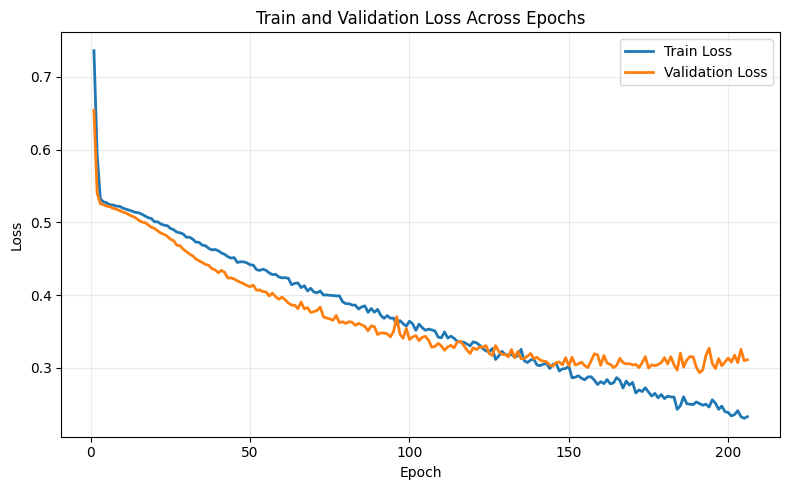

In [475]:
# Training with early stopping on validation loss. Set initial values
best_val_loss = float("inf") # start at maximum
best_state_dict = copy.deepcopy(model.state_dict()) 
patience_counter = 0

# Recorded values
train_loss_history = []
val_loss_history = []

print("\n========== Training Simple Workflow ==========%s" % "")

# Training loop
for epoch in range(epochs):
    model.train() # update parameters
    train_loss, train_total = 0.0, 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * xb.size(0)
        train_total += yb.size(0)

    train_loss /= max(train_total, 1)

    val_loss, _, _, _ = evaluate(val_loader, model, criterion, threshold=0.5)

    train_loss_history.append(train_loss)
    val_loss_history.append(val_loss)

    # Patience counter increase condition (validation loss increases)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state_dict = copy.deepcopy(model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1

    print(
        f"Epoch [{epoch+1}/{epochs}] ",
        f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Patience: {patience_counter}/{patience}"
    )

    if patience_counter >= patience:
        print(f"Early stopping triggered at epoch {epoch+1}.")
        break

model.load_state_dict(best_state_dict)
torch.save(model.state_dict(), "trained_model.pt")
print("Best model saved as trained_model.pt")

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(train_loss_history) + 1), train_loss_history, linewidth=2, label='Train Loss')
plt.plot(range(1, len(val_loss_history) + 1), val_loss_history, linewidth=2, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Train and Validation Loss Across Epochs')
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

If the training process is successful, we should observe the loss curves decreasing rapidly at the beginning and then continuing to decline more gradually. Eventually, the validation loss may start increasing while the training loss keeps decreasing, indicating that the model is beginning to overfit. At this point, the early stopping mechanism interrupts the training process. If the curves do not exhibit this expected behavior, we recommend adjusting the learning rate accordingly.

### **Model Evaluation**

In this section, we evaluate the model using several performance metrics. The most important metric is the AUC-ROC, which reflects the model’s overall discriminative ability. Sensitivity and specificity can be easily tuned by adjusting the decision threshold according to a specific objective (in our case maximizing balanced accuracy). It is important to grasp how threhold selection influences predictions:

- Higher threshold -> fewer positive predictions
- Lower threshold -> more positive predictions

Sensitivity (TPR: how many true positives are detected) and specificity (TNR: how many true negatives are detected) are defined below:
$$
TPR = \frac{TP}{TP + FN}
$$

$$
TNR = \frac{TN}{TN + FP}
$$
 
Accuracy (Ac) and balanced accuracy (BAc) are defined below. We selected balanced accuracy as our primary metric for guiding the decision threshold, as it accounts for both sensitivity and specificity. In this context, injury events are mainly associated with excessive workload and do not pose an immediate threat to the subject’s life; therefore, sensitivity was not considered as critical as in other scenarios.

$$
Ac = \frac{TN + TP}{TN + TP + FN + FP}
$$

$$
BAc = \frac{TNR + TPR}{2}
$$

Best threshold (validated on validation set): 0.25
Validation balanced accuracy at best threshold: 0.8371
Validation ROC AUC: 0.9190
Test Loss: 0.3842
Test Accuracy: 0.8872
Test Specificity (TNR): 0.8913
Test Sensitivity (TPR): 0.6667
Test Balanced Accuracy: 0.7790
Test ROC AUC: 0.8656


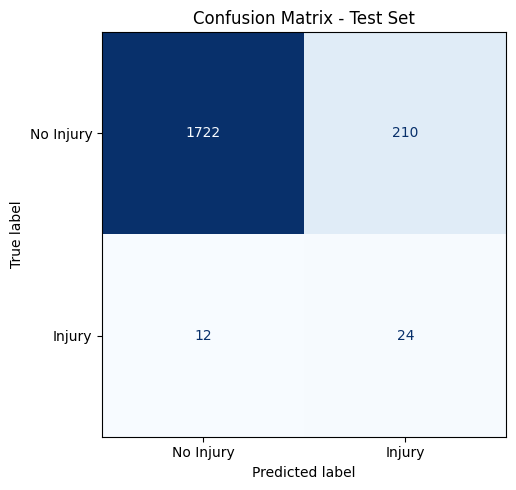

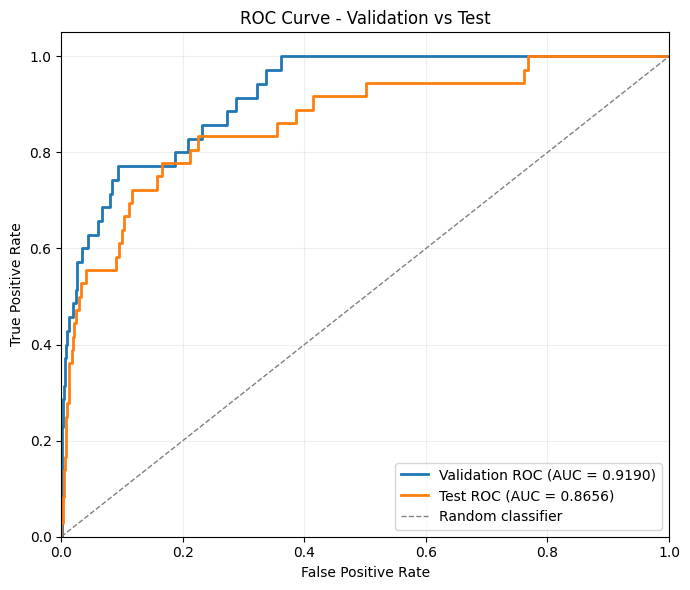

In [ ]:
# Over a vast grid of thresholds, select the one maximizing balanced accuracy in validation set
threshold_grid = np.linspace(0.01, 0.99, 99)
_, y_val_true, y_val_probs, _ = evaluate(val_loader, model, criterion, threshold=0.5)
val_balanced_accuracy_scores = []

for threshold in threshold_grid:
    val_preds = (y_val_probs >= threshold).astype(int)
    val_balanced_accuracy_scores.append(balanced_accuracy_score(y_val_true, val_preds))

best_threshold = threshold_grid[int(np.argmax(val_balanced_accuracy_scores))]
best_val_balanced_accuracy = float(np.max(val_balanced_accuracy_scores))

# Compute validation ROC/AUC
val_fpr, val_tpr, _ = roc_curve(y_val_true, y_val_probs)
val_roc_auc = auc(val_fpr, val_tpr)

test_loss, y_test_true, y_test_probs, y_test_pred = evaluate(
    test_loader, model, criterion, threshold=best_threshold
)

# Compute the evaluation metrics for test set
test_accuracy = accuracy_score(y_test_true, y_test_pred)
test_balanced_accuracy = balanced_accuracy_score(y_test_true, y_test_pred)
test_roc_auc = roc_auc_score(y_test_true, y_test_probs)
cm = confusion_matrix(y_test_true, y_test_pred)
fpr, tpr, _ = roc_curve(y_test_true, y_test_probs)
roc_auc = auc(fpr, tpr)

# Compute sensitivity and specificity from confusion matrix
tn, fp, fn, tp = cm.ravel()

test_sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
test_specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

print(f"Best threshold (validated on validation set): {best_threshold:.2f}")
print(f"Validation balanced accuracy at best threshold: {best_val_balanced_accuracy:.4f}")
print(f"Validation ROC AUC: {val_roc_auc:.4f}")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Specificity (TNR): {test_specificity:.4f}")
print(f"Test Sensitivity (TPR): {test_sensitivity:.4f}")
print(f"Test Balanced Accuracy: {test_balanced_accuracy:.4f}")
print(f"Test ROC AUC: {test_roc_auc:.4f}")

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Injury', 'Injury'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues', values_format='d', colorbar=False)
ax.set_title('Confusion Matrix - Test Set')
plt.tight_layout()
plt.show()

# Plot Validation and Test ROC curves together
plt.figure(figsize=(7, 6))
plt.plot(val_fpr, val_tpr, label=f'Validation ROC (AUC = {val_roc_auc:.4f})', linewidth=2, color='#1f77b4')
plt.plot(fpr, tpr, label=f'Test ROC (AUC = {roc_auc:.4f})', linewidth=2, color='#ff7f0e')
plt.plot([0, 1], [0, 1], linestyle='--', linewidth=1, label='Random classifier', color='grey')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Validation vs Test')
plt.legend(loc='lower right')
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

The ROC curves and confusion matrix highlight that our model performs a pretty decent prediction of injury label, despite data limitations